# **Titanic Project**

**About Dataset:** 

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

**Target**:

To predict what sorts of people were more likely to survive i.e "Survived" column  in the Dataset.

**Approach**:

In this Project firstly, I will display some feature analysis then ill focus on feature engineering. Last part concerns modeling and predicting the survival on the Titanic using a voting procedure.
In the modeling,I've used support vector classifier.

# Importing Libraries

In [85]:
import numpy as np # linear algebra
import pandas as pd # data processing

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv


In [86]:
import numpy as np 
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Getting dataset

In [87]:

train_data=pd.read_csv("/kaggle/input/titanic/train.csv")
test_data=pd.read_csv("/kaggle/input/titanic/test.csv")

#This displays first 5 data from the training-dataset
train_data.head()
#observation: the dataset consists of categorical variable and a few numerical variables.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
train_data.tail()
#displaying bottom 5 data from the training-dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [89]:
#Finding dimensions
print("number of rows in traning set",train_data.shape[0])
print("number of columns in training set",train_data.shape[1])
print("number of rows in test set",test_data.shape[0])
print("number of columns in test set",test_data.shape[1])

number of rows in traning set 891
number of columns in training set 12
number of rows in test set 418
number of columns in test set 11


# **Exploratory Data Analysis**

In [90]:
train_data.isna().sum()
#Here Age,Cabin and Embarked have missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [91]:
test_data.isna().sum()
#here Age,Fare,Cabin have missing values

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

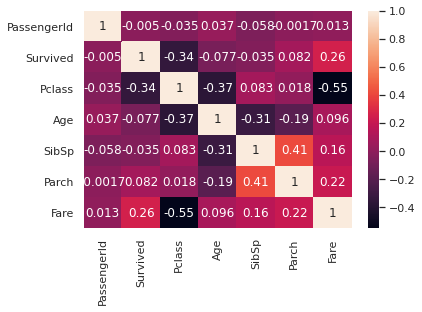

In [92]:
# Data preprocessing
sns.heatmap(train_data.corr(),annot=True)
#Age is correlated to PCLASS the most with correlation coff=-0.37.

In [93]:
df=train_data.groupby('Pclass',as_index=False)['Age'].median()
df.head()

,Pclass,Age
0,1,37.0
1,2,29.0
2,3,24.0


In [94]:
#Replacing missing vales in training set
#AGE
for i,row in train_data.iterrows():
    if(np.isnan(train_data['Age'][i])==True):
        if(train_data['Pclass'][i]==1):
            train_data['Age'][i]=37.0
        elif(train_data['Pclass'][i]==2):
            train_data['Age'][i]=29.0
        else:
            train_data['Age'][i]=24.0
#CABIN (It has maximum number of missing values and hence it will NOT be worth a feature to work on. Still we will replace
#the missing values with its mode)
train_data['Cabin']=train_data['Cabin'].fillna(train_data['Cabin'].mode()[0])
#EMBARKED
#For this we have two missing values each having equivalent Fare of $80 and same PClass,same ticketnumber this
#means that they had to board from the same station.And on google search, I got to know that she boarded from SouthHampton.
#This means that Both of them boarded from SouthHampton.
train_data['Embarked']=train_data['Embarked'].fillna('S')

In [95]:
train_data.info()
#no missing values in training set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [96]:
df=test_data.groupby('Pclass',as_index=False)['Age'].median()
df.head()

,Pclass,Age
0,1,42.0
1,2,26.5
2,3,24.0


In [97]:
#Replacing Missing Values in Test Set
#AGE
for i,row in test_data.iterrows():
    if(np.isnan(test_data['Age'][i])==True):
        if(test_data['Pclass'][i]==1):
            test_data['Age'][i]=42.0
        elif(test_data['Pclass'][i]==2):
            test_data['Age'][i]=26.0
        else:
            test_data['Age'][i]=24.0
#CABIN
test_data['Cabin']=test_data['Cabin'].fillna(test_data['Cabin'].mode()[0])
#FARE
#We can see that Fare is most correlated to Pclass and hence it should be computed by median of fare grouped by pclass.
#As the person belonged to class 3, we will take median of class 3.

In [98]:
df=test_data.groupby('Pclass',as_index=False)['Fare'].median()
df.head()

,Pclass,Fare
0,1,60.0000
1,2,15.7500
2,3,7.8958


In [99]:
test_data['Fare']=test_data['Fare'].fillna(7.89)
test_data.isna().sum()
#NO MISSING VALUES

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# Visualizng Dataset

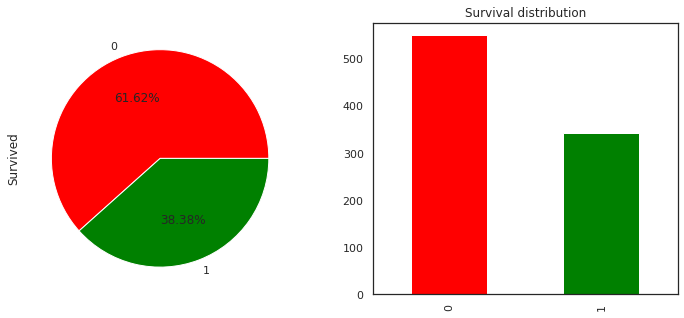

In [100]:
# DATA VISUALIZATION
plt.figure(figsize=(12,5))
plt.subplot(121)
train_data['Survived'].value_counts().plot.pie(autopct='%0.2f%%',colors=['red','green'])
plt.subplot(122)
plt.title('Survival distribution')
train_data.Survived.value_counts().plot(kind='bar',color=['red','green'])

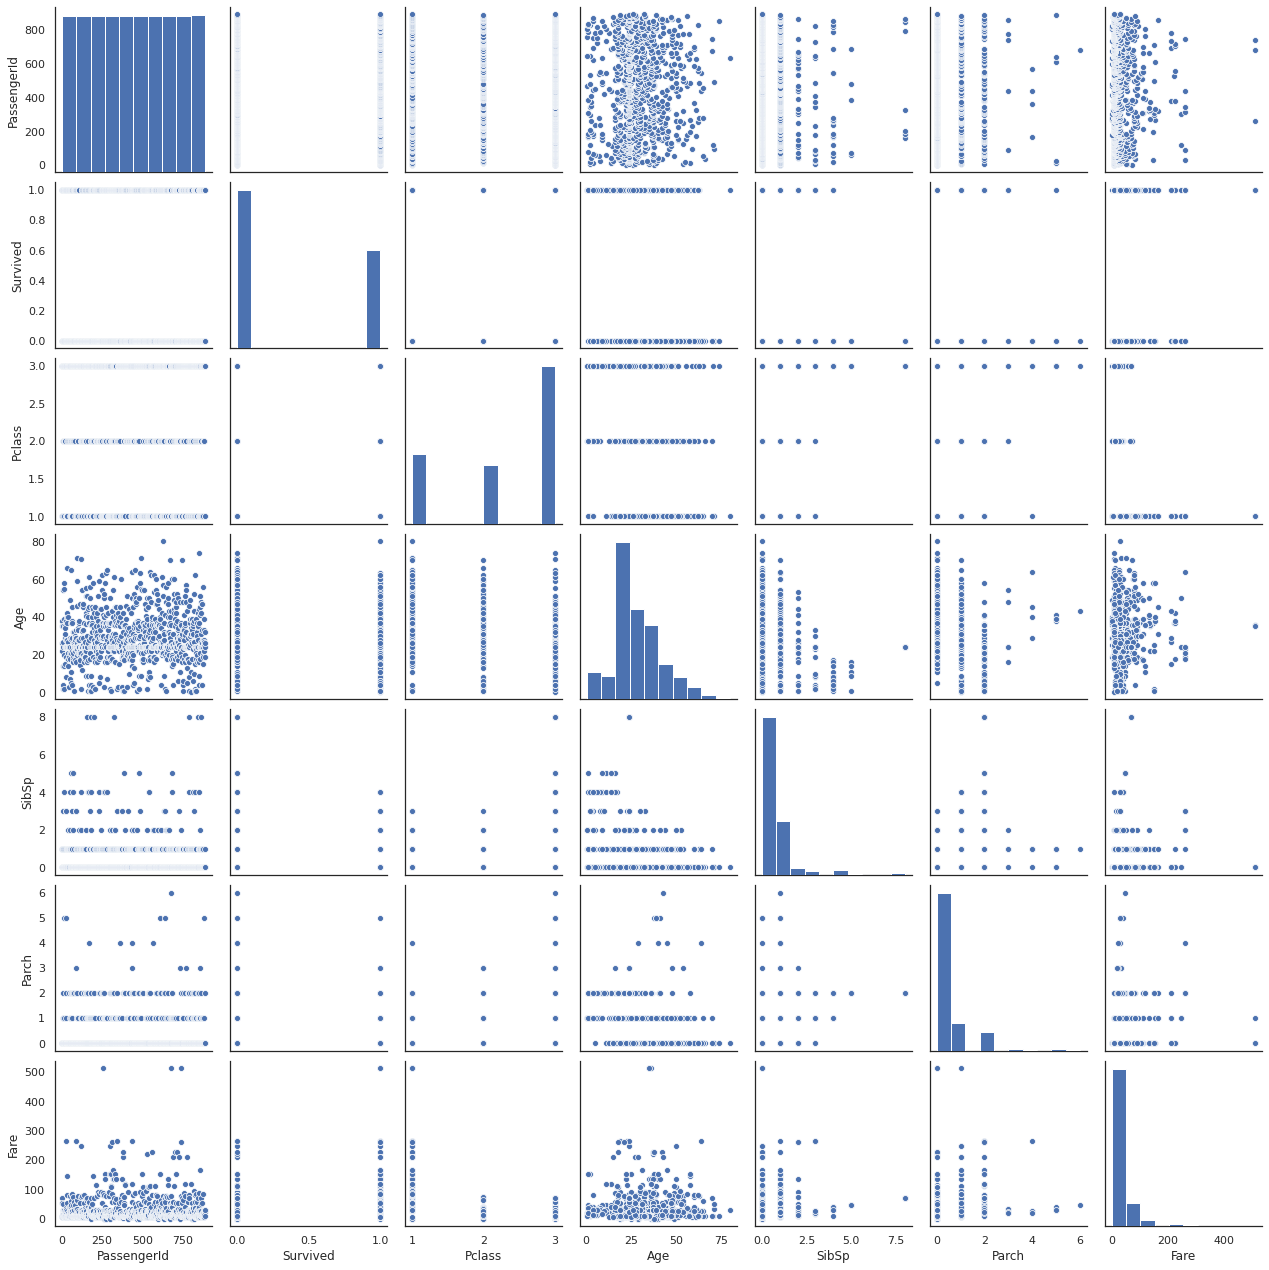

In [101]:
sns.pairplot(train_data)

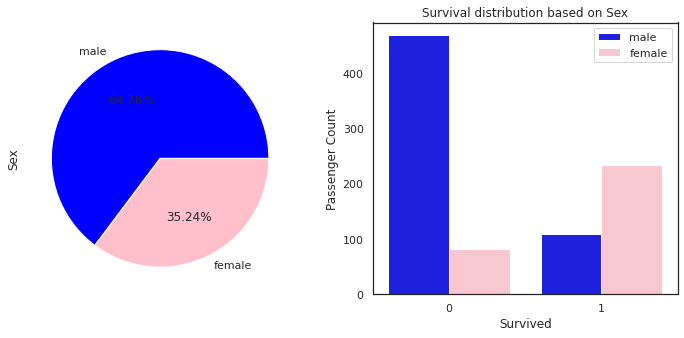

In [102]:
plt.figure(figsize=(12,5))
plt.subplot(121)
train_data['Sex'].value_counts().plot.pie(autopct='%0.2f%%',colors=['blue','pink'])
plt.subplot(122)
sns.countplot(x = 'Survived',data = train_data,hue = 'Sex',palette=['blue','pink'])
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.title('Survival distribution based on Sex')
plt.legend()

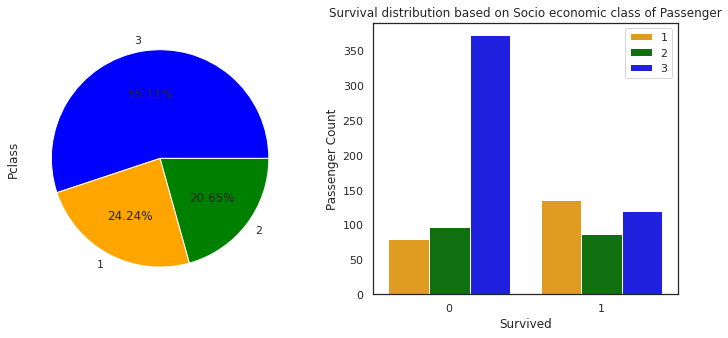

In [103]:
plt.figure(figsize=(12,5))
plt.subplot(121)
train_data['Pclass'].value_counts().plot.pie(autopct='%0.2f%%',colors=['blue','orange','green'])
plt.subplot(122)
sns.countplot(x = 'Survived',data = train_data,hue = 'Pclass',palette=['orange','green','blue'])
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.title('Survival distribution based on Socio economic class of Passenger')
plt.legend()

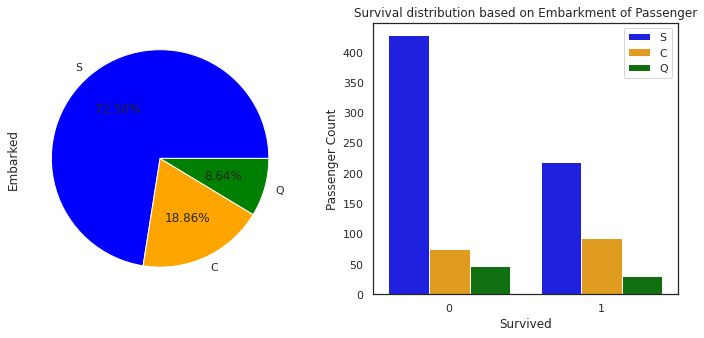

In [104]:
plt.figure(figsize=(12,5))
plt.subplot(121)
train_data['Embarked'].value_counts().plot.pie(autopct='%0.2f%%',colors=['blue','orange','green'])
plt.subplot(122)
sns.countplot(x = 'Survived',data = train_data,hue = 'Embarked',palette=['blue','orange','green'])
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.title('Survival distribution based on Embarkment of Passenger')
plt.legend()

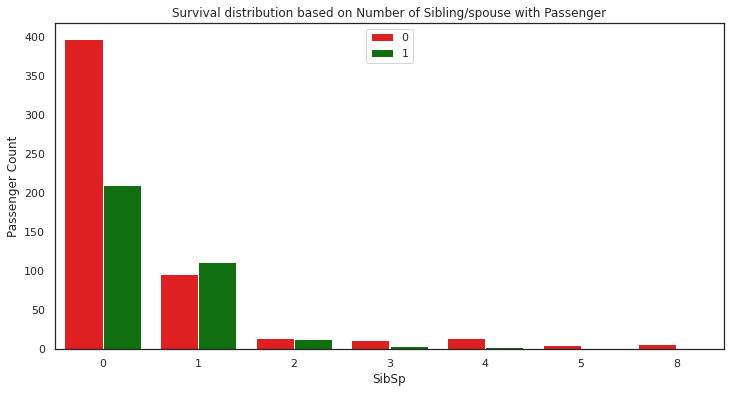

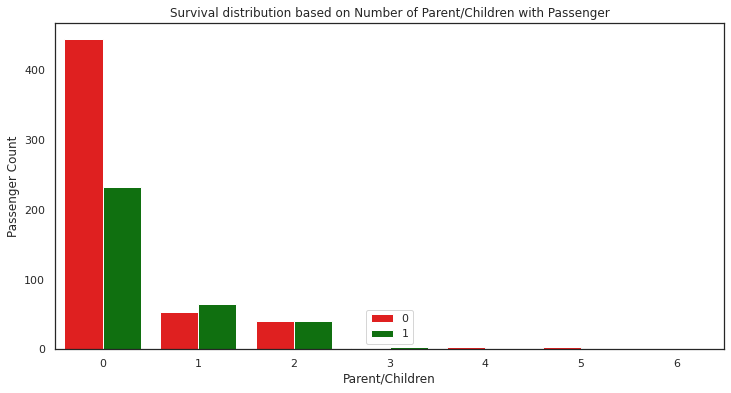

In [105]:
plt.figure(figsize=(12,6))
sns.countplot(x = 'SibSp',data = train_data,hue = 'Survived',palette=['red','green'])
plt.xlabel('SibSp')
plt.ylabel('Passenger Count')
plt.title('Survival distribution based on Number of Sibling/spouse with Passenger')
plt.legend()

plt.figure(figsize=(12,6))
sns.countplot(x = 'Parch',data = train_data,hue = 'Survived',palette=['red','green'])
plt.xlabel('Parent/Children')
plt.ylabel('Passenger Count')
plt.title('Survival distribution based on Number of Parent/Children with Passenger')
plt.legend()

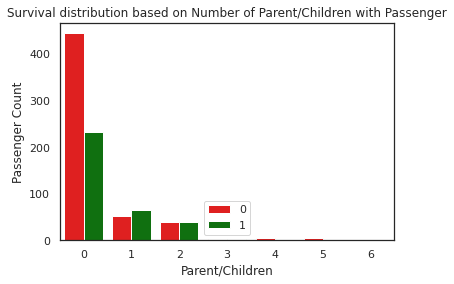

In [106]:
sns.countplot(x = 'Parch',data = train_data,hue = 'Survived',palette=['red','green'])
plt.xlabel('Parent/Children')
plt.ylabel('Passenger Count')
plt.title('Survival distribution based on Number of Parent/Children with Passenger')
plt.legend()

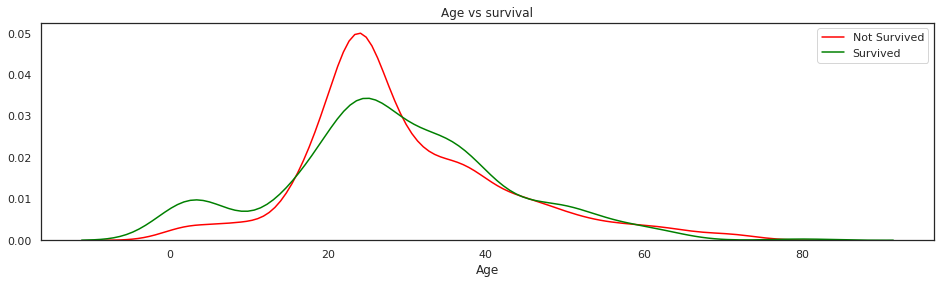

In [107]:
plt.figure(figsize=(16,4))
plt.title('Age vs survival')
sns.distplot(train_data['Age'][train_data['Survived']==0],bins=20,kde=True,hist=False,kde_kws={"color": "red", "label": "Not Survived"})
sns.distplot(train_data['Age'][train_data['Survived']==1],bins=20,kde=True,hist=False,kde_kws={"color": "green", "label": "Survived"})

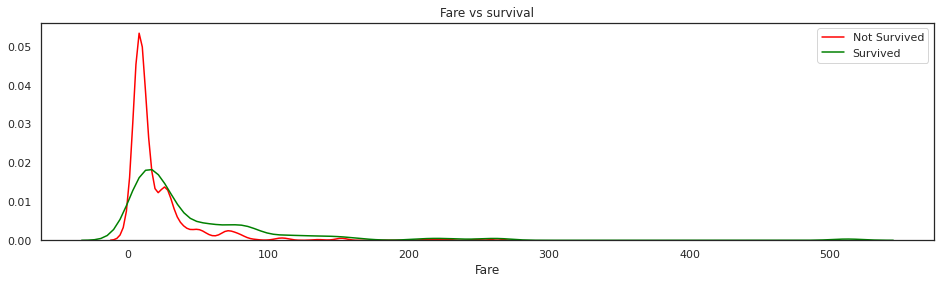

In [108]:
plt.figure(figsize=(16,4))
plt.title('Fare vs survival')
sns.distplot(train_data['Fare'][train_data['Survived']==0],bins=10,kde=True,hist=False,kde_kws={"color": "red", "label": "Not Survived"})
sns.distplot(train_data['Fare'][train_data['Survived']==1],bins=10,kde=True,hist=False,kde_kws={"color": "green", "label": "Survived"})

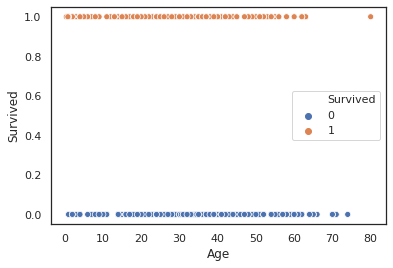

In [109]:
sns.scatterplot(data=train_data,x='Age',y='Survived',hue='Survived')

In [110]:
traindata=train_data.drop(['Name','Ticket','Cabin','PassengerId','Fare','SibSp','Age'],axis=1)
testdata=test_data.drop(['Name','Ticket','Cabin','PassengerId','Fare','SibSp','Age'],axis=1)
traindata.head()

,Survived,Pclass,Sex,Parch,Embarked
0,0,3,male,0,S
1,1,1,female,0,C
2,1,3,female,0,S
3,1,1,female,0,S
4,0,3,male,0,S


In [111]:
X_train=traindata.iloc[:,1:]
y_train=traindata.iloc[:,0]
X_train=pd.get_dummies(X_train,['Sex','Embarked'])
X_test=testdata.iloc[:,:]
X_test=pd.get_dummies(X_test,['Sex','Embarked'])

# Modelling using Support Vector Classifier 

In [112]:
from sklearn.svm import SVC
classifier=SVC(kernel='rbf')
classifier.fit(X_train,y_train)

SVC()

In [113]:
y_train_predict=classifier.predict(X_train)
y_test=classifier.predict(X_test)

In [114]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,classification_report
print('Accuracy for training set is: ',accuracy_score(y_train,y_train_predict))
print('AUC SCORE for training set: ',roc_auc_score(y_train,y_train_predict))


Accuracy for training set is:  0.813692480359147
AUC SCORE for training set:  0.7705397373214457


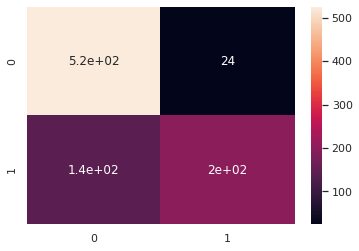

In [115]:
cm=confusion_matrix(y_train,y_train_predict)
sns.heatmap(cm,annot=True)

In [116]:
print(classification_report(y_train,y_train_predict))

              precision    recall  f1-score   support

           0       0.79      0.96      0.86       549
           1       0.89      0.58      0.71       342

    accuracy                           0.81       891
   macro avg       0.84      0.77      0.79       891
weighted avg       0.83      0.81      0.80       891



In [117]:
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': y_test})
output.to_csv('svc-titanic.csv', index=False)


**We have got 81% accuracy using support vector classifier.**

Please, upvote my work if it could help! Thank you!